Source: Based on the Kaggle Notebook https://www.kaggle.com/code/juniam/natural-language-processing-cancer-95/notebook  
Notes: 加上了詳細的中文註解與未來可優化的紀錄

In [91]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neural_network import MLPClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
import numpy as np
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

In [92]:
df = pd.read_csv('medquad.csv')
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16412 entries, 0 to 16411
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   question    16412 non-null  object
 1   answer      16407 non-null  object
 2   source      16412 non-null  object
 3   focus_area  16398 non-null  object
dtypes: object(4)
memory usage: 513.0+ KB


In [93]:
#此處思路：篩選掉資料數太少的疾病

#str.upper 把focus_area裡的文字全部變成大寫（之後才好 Count）
#value_counts 計算出每個疾病共幾筆資料
#找出筆數大於20的疾病後，用index.tolist把它們的名字存成一個清單
#isin 篩選資料表，製作出一個充滿boolean值的清單
#利用 Boolean Masking/Boolean Indexing特性，把這組清單包進df裡面做出新的資料

df['focus_area'] = df['focus_area'].str.upper()
counts = df['focus_area'].value_counts()
classifications_to_keep = counts[counts > 20].index.tolist()
df = df[df['focus_area'].isin(classifications_to_keep)]

df.head()

,question,answer,source,focus_area
14,What is (are) High Blood Pressure ?,High blood pressure is a common disease in whi...,NIHSeniorHealth,HIGH BLOOD PRESSURE
15,What causes High Blood Pressure ?,Changes in Body Functions Researchers continue...,NIHSeniorHealth,HIGH BLOOD PRESSURE
16,Who is at risk for High Blood Pressure? ?,Not a Normal Part of Aging Nearly 1 in 3 Ameri...,NIHSeniorHealth,HIGH BLOOD PRESSURE
17,How to prevent High Blood Pressure ?,Steps You Can Take You can take steps to preve...,NIHSeniorHealth,HIGH BLOOD PRESSURE
18,What are the symptoms of High Blood Pressure ?,"High blood pressure is often called the ""silen...",NIHSeniorHealth,HIGH BLOOD PRESSURE


In [94]:
#將數據整理成最終樣子

#1. 篩選：先 drop掉表格裡不需要的直向欄位（source, question)，之後再利用 dropna刪掉有NaN的列
#2. 改名：把answer欄位的資料複製給新的text欄位，之後把answer欄位刪除（NLP領域的默契，要分析的文章欄位命名為text）
#3. 篩選：利用 str.contains找到 focus_area裡有含cancer字的資料，case=False 代表不分大小寫

df = df.drop(["source", "question"], axis=1).dropna()

df["text"] = df["answer"]
df = df.drop("answer", axis=1)

df = df[df['focus_area'].str.contains('cancer', case=False)]

df.head()

,focus_area,text
168,PROSTATE CANCER,How Tumors Form The body is made up of many ty...
169,PROSTATE CANCER,Scientists don't know exactly what causes pros...
170,PROSTATE CANCER,"Symptoms Most cancers in their early, most tre..."
171,PROSTATE CANCER,"If tests show that you have cancer, you should..."
172,PROSTATE CANCER,Choosing Treatment There are a number of ways ...


In [85]:
#機器學習前的數據貼標

#1. 把資料分成 X (特徵) 與 y (目標)，AI讀進去 X，而正解是 Y
#2. TfidfVectorizer：把單字轉換成「重要性分數」的工具，如果一個單字在某篇文章出現很多次，它就越重要（分數越高）
#2-1. max_df=0.6： 如果一個字在「超過 60% 的文章」裡都有出現，代表這個字太普通了（像是 "the"、"patient"、"is"），工具會直接把它忽略，不給它分數
#3. .fit_transform().toarray()：把 X 裡面所有的醫學文章，轉換成一個巨大且純數字的二維陣列（矩陣）

X = df["text"]
y = df["focus_area"]

tfidf = TfidfVectorizer(max_df=0.6) 
X = tfidf.fit_transform(X).toarray()

# EDA - Exploratory Data Analysis
Before we can do anything, we have to **understand what we are dealing with**. As such, there are a few key things.

- The **proportion of cancer types**
- How the TFIDF **scored the words**

This will be plotted out in the next cells.

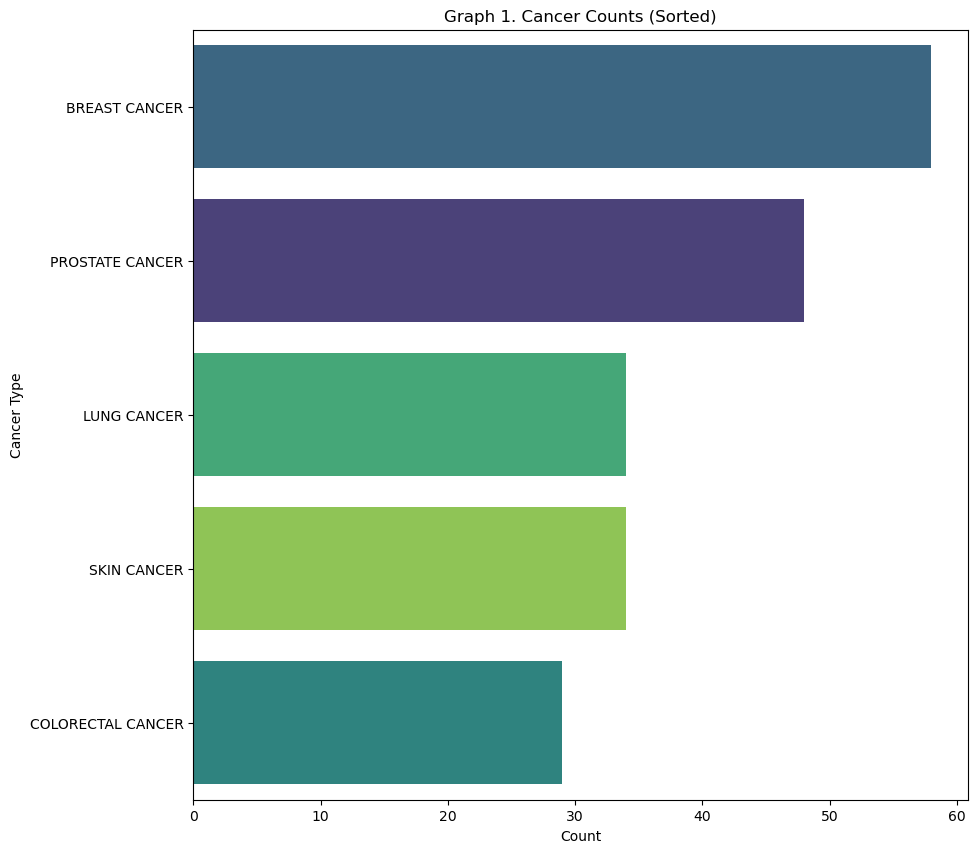

In [119]:
# Data Visualization
# EDA (Exploratory Data Analysis，探索性資料分析)：再把資料餵給AI之前，先畫圖了解數據的樣子

#1. 利用value_counts把癌症種類「由多到少」排好，之後用index排序
#2. 畫圖：設定畫布大小、呼叫Seaborn套件、countplot技術長條圖來呈現、設定ㄅ

ordered_specialties = df['focus_area'].value_counts().index

plt.figure(figsize=(10,10))
sns.countplot(y="focus_area", data=df, order=ordered_specialties, palette="viridis", hue="focus_area", legend=False)
plt.title("Graph 1. Cancer Counts (Sorted)")
plt.xlabel("Count")
plt.ylabel("Cancer Type")
plt.show()

In [135]:
#Graphing TFIDF Scores

# get_feature_names_out()：把所有的英文字母名單抽出來，用np.sum把text中特定單字的分數全部加總
# 用zip把左邊的英文字母名單和右邊的分數清單連接在一起，變成 (單字, 分數) 的清單，之後再塞回DataFrame結構中
# 排序：利用sort_values將分數從高分到低分（ascending=False遞減）
# 切分：[:50]只取前50份資料

feature_names = tfidf.get_feature_names_out()
word_tfidf_sums = np.sum(X, axis=0)
print(word_tfidf_sums)

word_scores = list(zip(feature_names, word_tfidf_sums))
df_word_scores = pd.DataFrame(word_scores, columns=['word', 'score'])
print(df_word_scores)

df_sorted = df_word_scores.sort_values(by='score', ascending=False)
df_sorted = df_sorted[:50]
print(df_sorted)

[0.19508959 0.86120862 0.81583165 ... 0.92620424 4.60755679 0.0123603 ]
             word     score
0              00  0.195090
1             000  0.861209
2              10  0.815832
3             100  0.022970
4              11  0.113493
...           ...       ...
2998          you  5.114038
2999        young  0.661897
3000      younger  0.926204
3001         your  4.607557
3002  zoledronate  0.012360

[3003 rows x 2 columns]
              word      score
393         breast  18.107880
2093      prostate  13.867631
2299          risk  11.486121
1575          lung  11.282675
2459          skin   9.911670
472          cells   9.900727
1622           may   8.627909
2790     treatment   8.413247
2713       therapy   7.860830
2795        trials   7.671269
555     colorectal   7.220633
1212          have   7.214495
2968          with   7.054325
529       clinical   6.916655
1797           not   6.639382
1651           men   6.536674
2140     radiation   6.480453
297             be   6.3303

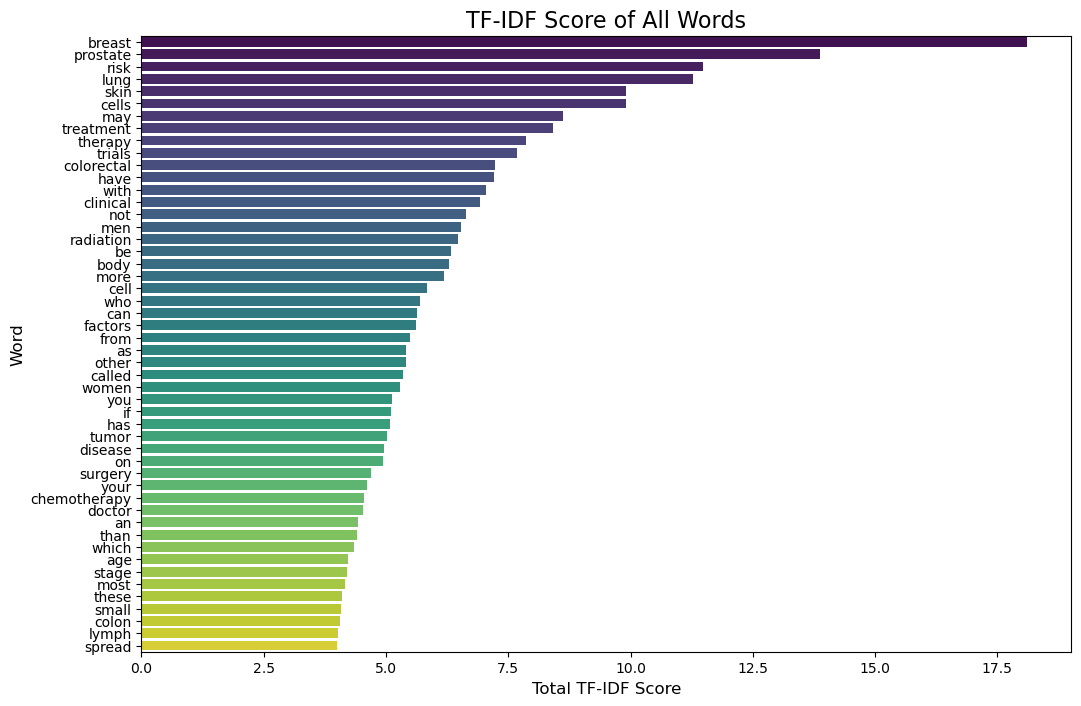

In [145]:
#畫圖

plt.figure(figsize=(12, 8))
ax = sns.barplot(
    data=df_sorted,
    x='score',
    y='word',
    palette='viridis',
    orient='h',
    hue="word", legend=False
)
ax.set_title('TF-IDF Score of All Words', fontsize=16)
ax.set_xlabel('Total TF-IDF Score', fontsize=12)
ax.set_ylabel('Word', fontsize=12)
plt.show()

In [7]:
model= VotingClassifier(estimators=[('RF', RandomForestClassifier(random_state=42, n_jobs=-1, n_estimators=10, max_depth=3)), ('GBC', GradientBoostingClassifier(random_state=42, n_estimators=10, max_depth=3)), ('MLP', MLPClassifier(random_state=42, max_iter=300)), ("SGD", SGDClassifier(random_state=42, loss="modified_huber")), ("DT", DecisionTreeClassifier(random_state=42, max_depth=3))],
        voting='soft')

In [8]:
model.fit(X_train,y_train)

VotingClassifier(estimators=[('RF',
                              RandomForestClassifier(max_depth=3,
                                                     n_estimators=10, n_jobs=-1,
                                                     random_state=42)),
                             ('GBC',
                              GradientBoostingClassifier(n_estimators=10,
                                                         random_state=42)),
                             ('MLP',
                              MLPClassifier(max_iter=300, random_state=42)),
                             ('SGD',
                              SGDClassifier(loss='modified_huber',
                                            random_state=42)),
                             ('DT',
                              DecisionTreeClassifier(max_depth=3,
                                                     random_state=42))],
                 voting='soft')

In [9]:
y_pred=model.predict(X_test)

In [10]:
acc=round((accuracy_score(y_test,y_pred)*100),1)